<a href="https://colab.research.google.com/github/angelfrancomorales/INFO648/blob/main/Lesson9/Student_INFO_648_LSN9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  1. Supervised Machine Learning, Classification, and Decision Trees


🌳 What is a Decision Tree?

A Decision Tree is a supervised machine learning model used for classification (predicting categories) and regression (predicting numbers).

It works by splitting data into smaller and smaller groups based on feature values, forming a structure that looks like an upside-down tree.

Key Components

* Root Node
The first split — uses the feature that best separates the data.

* Branches
The outcomes of each decision (Yes/No, True/False).

* Leaf Nodes
Final predictions (class label or numeric value).


Why Decision Trees Are Popular

* Easy to visualize
* Handles numeric + categorical data
* Requires little preprocessing
* Captures non-linear relationships

## Decision Tree Example

```
                 Is GPA > 3.0?
                 /           \
               Yes            No
               /               \
      Predict: Pass     Is Attendance > 80%?
                         /             \
                       Yes              No
                       /                 \
              Predict: Pass        Predict: Fail
```


In [1]:
import pandas as pd

In [3]:
df=pd.read_csv('cps_with_education_clean (1).csv')

In [4]:
df.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,197,2020,40,1350.0,43,1,23,Some College
1,224,2020,40,1310.0,64,2,23,Bachelor's
2,323,2020,40,1020.0,51,2,23,Graduate / Professional
3,324,2020,40,1350.0,52,1,23,Graduate / Professional
4,353,2020,50,1310.0,37,2,23,Some College


In [5]:
df.describe()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,2.476180e+05,247618.000000,247618.000000,247618.000000,247618.000000,247618.000000,247618.000000
mean,2.896190e+06,2023.358068,43.011150,2045.742057,44.728542,1.415289,27.981920
std,1.572192e+06,1.217079,7.245386,1478.484148,12.432250,0.492773,16.316574
min,1.970000e+02,2020.000000,21.000000,1002.000000,15.000000,1.000000,1.000000
25%,1.536342e+06,2022.000000,40.000000,1270.000000,35.000000,1.000000,12.000000
50%,2.928244e+06,2023.000000,40.000000,1630.000000,44.000000,1.000000,28.000000
75%,4.228782e+06,2024.000000,45.000000,2300.000000,54.000000,2.000000,42.000000
max,5.553888e+06,2025.000000,80.000000,13258.230000,85.000000,2.000000,56.000000


In [6]:
model_df=df

In [8]:
high_pay=model_df['EARNWEEK2'].median()

## 2. Defining the Target Variable: high_earner

We create a target variable called high_earner by labeling individuals who earn above the median weekly earnings as 1 and those at or below the median as 0. This converts a continuous income variable into a binary outcome that is suitable for classification.

Because high_earner can only take the values 0 or 1, it is a categorical target, not a numeric one, even though it is represented using numbers.

high\_earner =
\begin{cases}
1 & \text{if } \text{EARNWEEK2} > \text{median(EARNWEEK2)} \\
0 & \text{otherwise}
\end{cases}

In [10]:
model_df['high_earner']=(model_df['EARNWEEK2']>high_pay).astype(int)

In [11]:
model_df.head(15)

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education,high_earner
0,197,2020,40,1350.0,43,1,23,Some College,0
1,224,2020,40,1310.0,64,2,23,Bachelor's,0
2,323,2020,40,1020.0,51,2,23,Graduate / Professional,0
3,324,2020,40,1350.0,52,1,23,Graduate / Professional,0
4,353,2020,50,1310.0,37,2,23,Some College,0
5,362,2020,50,1210.0,53,2,23,Graduate / Professional,0
6,452,2020,60,1600.0,69,1,23,Master's,0
7,484,2020,50,2885.0,60,1,23,Graduate / Professional,1
8,493,2020,40,1080.0,56,1,23,Bachelor's,0
9,632,2020,40,1580.0,58,1,23,Associate's,0


In [12]:
model_df['high_earner'].value_counts()

,count
high_earner,
0,125077
1,122541


In [16]:
from sklearn.model_selection import train_test_split
#Which ones go into the features and which go into the target?
#"AGE", "UHRSWORKT", "AGE", "UHRSWORKT","high_earner"
X = model_df[["AGE", "UHRSWORKT", "education","SEX"]]
y = model_df["high_earner"]



## 3. Train–Test Split

The train–test split divides the data into two separate sets: one used to train the model and one used to evaluate it. The model is allowed to learn only from the training data, while the test data is kept hidden until evaluation.

This separation helps us estimate how well the model will perform on new, unseen data and prevents us from overestimating model performance.





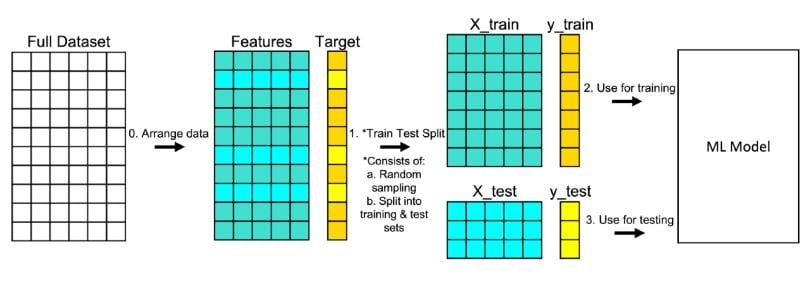

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y #makes sure the test and train have the rare target
)

In [21]:
#which go into numeric and which go into categorical

#"AGE", "UHRSWORKT","education", "SEX"
numeric_features = ["AGE", "UHRSWORKT"]
categorical_features = ["education", "SEX"]

We use the following features to predict whether someone is a high earner:

features = ["AGE", "UHRSWORKT", "education", "SEX"]


* AGE – numeric (continuous)

* UHRSWORKT (usual hours worked per week) – numeric (continuous)

* education – categorical (levels of educational attainment)

* SEX – categorical

**Because our features include both numeric and categorical data, they must be processed differently before being used in a machine learning model.**

In [ ]:
#which go into numeric and which go into categorical

#"AGE", "UHRSWORKT","education", "SEX"
numeric_features = [ ]
categorical_features = [ ]


## Why We Scale Numeric Features

<font color='red'><b>We do not need to scale with Trees*</b></font>



## One-Hot Encoding

<font color='red'><b>We do not need to one hot encode with Trees - but we do with sklearn*</b></font>

Logistic regression requires numeric inputs and cannot directly interpret categorical values. One-hot encoding converts each category into a separate binary indicator variable:

x =
\begin{cases}
1 & \text{if the observation belongs to category } k \\
0 & \text{otherwise}
\end{cases}


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
#numeric_features
#categorical_features
preprocess = ColumnTransformer(
    transformers=[

        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder='passthrough' # This keeps the numerical columns as they are
)

## What a Pipeline Does in scikit-learn

A pipeline combines preprocessing steps and the machine learning model into a single workflow. This ensures that all transformations learned from the training data are applied consistently to the test data.

Pipelines help prevent data leakage, simplify code, and reflect how models are built and deployed in real-world applications.

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier#this is new


model = Pipeline([
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=5,min_samples_leaf=20))
])


In [50]:
#This time we will type the code to fit the model
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['education', 'SEX'])])),
                ('clf',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=20))])

## What model.fit() Does

Calling model.fit() trains the entire pipeline using the training data. During this step, preprocessing parameters (such as scaling ranges and category mappings) are learned, and the logistic regression model estimates its coefficients.

All learning occurs only on the training set, preserving the integrity of model evaluation.

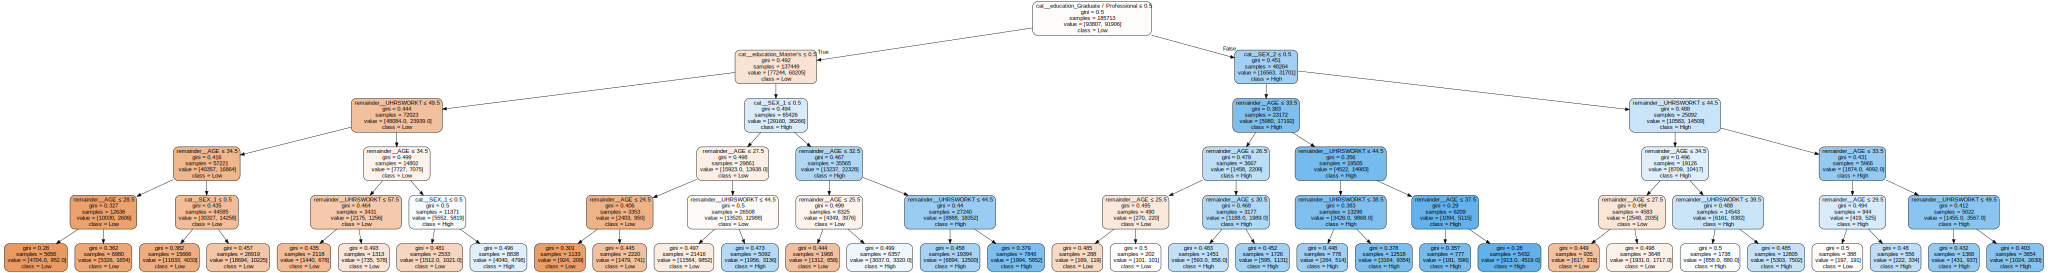

In [60]:
#this is just to let us see the tree
from sklearn.tree import export_graphviz
import graphviz

tree = model.named_steps["clf"]
feature_names = model.named_steps["prep"].get_feature_names_out()

dot = export_graphviz(
    tree,
    out_file=None,
    feature_names=feature_names,
    class_names=["Low", "High"],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=5
)

graphviz.Source(dot)


In [61]:
#this time we will run the prediction against the test data
y_pred=model.predict(X_test)

In [62]:
y_pred

array([0, 1, 1, ..., 1, 1, 1])

## ROC and AUC

Our model doesn't just output a label — it outputs a **probability** that each case is positive (`model.predict_proba`). To turn that into a yes/no decision we pick a **threshold**. A different threshold gives a different confusion matrix, so there's no single "accuracy" — there's a whole trade-off.

The **ROC curve** plots that trade-off across *every* threshold:

- **y-axis — True Positive Rate (TPR / recall):** $\frac{TP}{TP+FN}$ — of the real positives, how many did we catch?
- **x-axis — False Positive Rate (FPR):** $\frac{FP}{FP+TN}$ — of the real negatives, how many did we wrongly flag?

As we sweep the threshold from 1.0 down to 0.0, we trace the curve from $(0,0)$ to $(1,1)$. Each point is one possible operating point; **which one we choose depends on the cost of each error.**

**AUC** (Area Under the Curve) summarizes the whole curve in one number:

- $0.5$ = no better than random (the dashed diagonal)
- higher is better; $1.0$ = perfect ranking
- It's the probability the model ranks a random positive above a random negative — and it doesn't depend on the threshold.

> **Note:** a single decision tree only outputs a few distinct probabilities, so its ROC looks **blocky/stair-stepped** rather than smooth. That's expected — a random forest would smooth it out.

In [64]:
from sklearn.metrics import roc_auc_score
#Now we use the predict_proba to get the AUC
roc_auc_score(y_test,model.predict_proba(X_test)[:,1])

np.float64(0.6995746565514539)

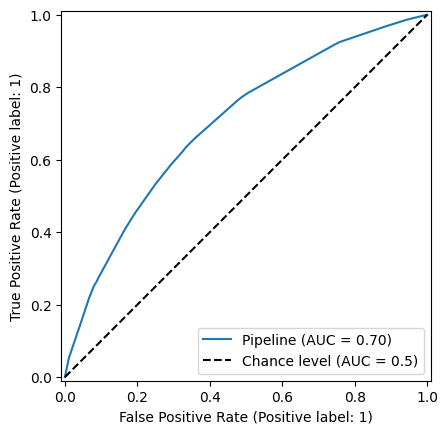

In [63]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model,X_test,y_test,plot_chance_level=True)

| Actual \\ Predicted | Predicted 0 (Negative) | Predicted 1 (Positive) |
|--------------------|------------------------|------------------------|
| **Actual 0 (Negative)** | True Negative (TN) | False Positive (FP) |
| **Actual 1 (Positive)** | False Negative (FN) | True Positive (TP) |


___________________________________________
___________________________________________

| Actual \\ Predicted | Not High Earner (0) | High Earner (1) |
|--------------------|--------------------|----------------|
| **Not High Earner (0)** | True Negative (TN) | False Positive (FP) |
| **High Earner (1)** | False Negative (FN) | True Positive (TP) |



In [65]:
from sklearn.metrics import confusion_matrix, classification_report
#Actual first
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[20824 10446]
 [11196 19439]]
              precision    recall  f1-score   support

           0       0.65      0.67      0.66     31270
           1       0.65      0.63      0.64     30635

    accuracy                           0.65     61905
   macro avg       0.65      0.65      0.65     61905
weighted avg       0.65      0.65      0.65     61905



Can we make the model better by tuning the model (changing splits and leaves and such). Will changing the threshold help us get those big donors??

In [66]:
#predict_proba is just like predict but it gives us the probabilites
y_prob = model.predict_proba(X_test)[:, 1]


In [67]:
y_prob

array([0.46002988, 0.54288301, 0.5858649 , ..., 0.54288301, 0.54288301,
       0.52225893])

In [68]:
#Let's change the cut off to 0.48 and see if that matters
y_pred_Num = (y_prob >= 0.48).astype(int)
print(confusion_matrix(y_test, y_pred_Num))
print(classification_report(y_test, y_pred_Num, digits=3))


[[20704 10566]
 [11080 19555]]
              precision    recall  f1-score   support

           0      0.651     0.662     0.657     31270
           1      0.649     0.638     0.644     30635

    accuracy                          0.650     61905
   macro avg      0.650     0.650     0.650     61905
weighted avg      0.650     0.650     0.650     61905



Now lets say we are given a new list of donors - lets predict if they are big salaries.

In [70]:
new_data=pd.read_csv('/content/new_donors.csv')

In [69]:
new_data

,Unnamed: 0,AGE,UHRSWORKT,education,SEX
0,0,25,40,Bachelor's,Male
1,1,42,40,Master's,Female
2,2,37,60,Master's,Male
3,3,29,35,Graduate/Professional,Female
4,4,55,45,High School,Male


In [71]:
#Predict
model.predict(new_data)

array([0, 0, 1, 0, 0])

In [72]:
model.predict_proba(new_data)

array([[0.83168317, 0.16831683],
       [0.53997012, 0.46002988],
       [0.38413197, 0.61586803],
       [0.76303725, 0.23696275],
       [0.74256351, 0.25743649]])